### Импорты

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import het_arch

from arch import arch_model

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

### Вспомогательные функции

In [2]:
def adf_pvalue(x):
    x = pd.Series(x).dropna().astype(float)
    return adfuller(x.values)[1]

def plot_series(x, title):
    plt.figure(figsize=(12, 4))
    plt.plot(x.index, x.values)
    plt.title(title)
    plt.tight_layout()
    plt.show()

### Загрузка ряда DowJones

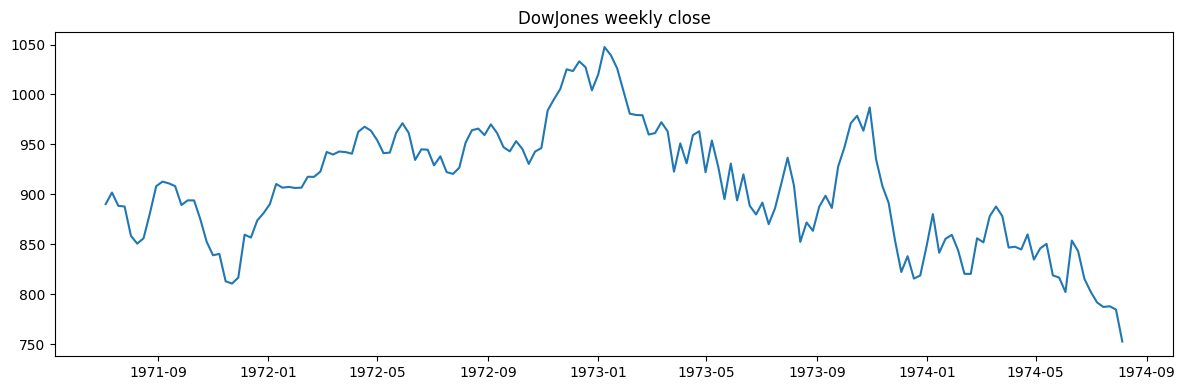

ADF p-value (close): 0.6224548515589717


In [3]:
df = pd.read_csv('weekly-closings-of-the-dowjones-.csv')
idx = pd.to_datetime(df['Week'] + '-1', format='%G-W%V-%u')
close = pd.Series(df['Close'].astype(float).values, index=idx, name='close')

plot_series(close, 'DowJones weekly close')
print('ADF p-value (close):', adf_pvalue(close))

### Приведение к стационарности

GARCH требует стационарный ряд, поэтому работаем не с уровнями, а с **лог-доходностями**.

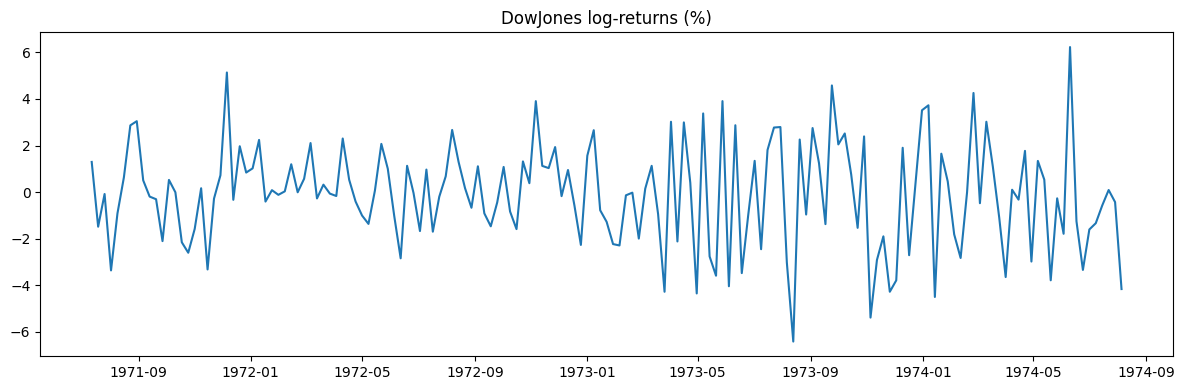

ADF p-value (returns): 2.7516091322913837e-24


In [4]:
ret = 100 * np.log(close).diff().dropna()
ret.name = 'ret'

plot_series(ret, 'DowJones log-returns (%)')
print('ADF p-value (returns):', adf_pvalue(ret))

### Подбор оптимальных параметров ARIMA по AIC

Так как ряд доходностей уже стационарный, фиксируем `d=0` и подбираем `p, q`.

In [5]:
def find_best_arima(ts, p_max=5, q_max=5):
    best_aic = np.inf
    best_order = None
    best_model = None
    
    for p in range(p_max + 1):
        for q in range(q_max + 1):
            try:
                model = ARIMA(ts, order=(p, 0, q), trend='n').fit()
                if model.aic < best_aic:
                    best_aic = model.aic
                    best_order = (p, 0, q)
                    best_model = model
            except Exception:
                pass
    
    return best_aic, best_order, best_model

aic, order, arima_model = find_best_arima(ret, p_max=5, q_max=5)
print('Best ARIMA by AIC:', order, 'AIC:', aic)

Best ARIMA by AIC: (2, 0, 2) AIC: 712.8489935409252


### Диагностика остатков ARIMA и тест на ARCH-эффект

Если ARCH-эффект есть (p-value < 0.05), то GARCH обычно уместен.

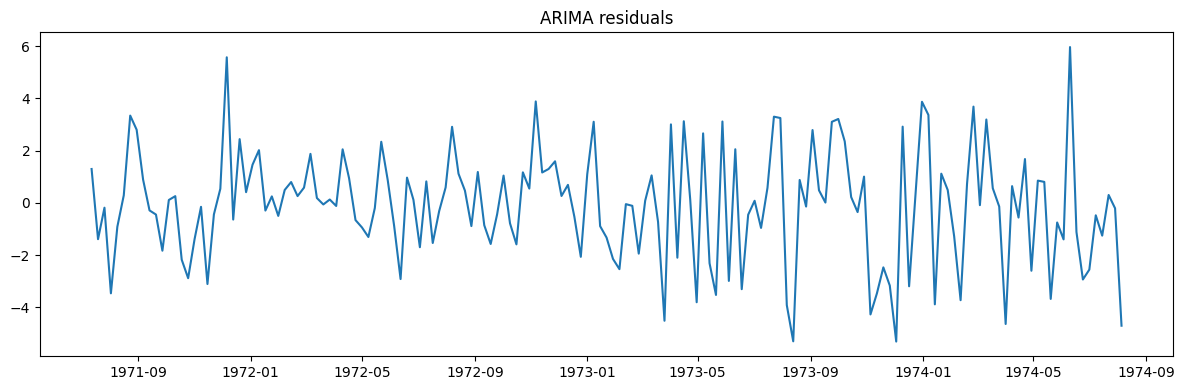

ARCH LM p-value: 0.2996332602964134


In [6]:
arima_resid = pd.Series(arima_model.resid, index=ret.index).dropna()
plot_series(arima_resid, 'ARIMA residuals')

lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(arima_resid.values)
print('ARCH LM p-value:', lm_pvalue)

### Построение GARCH на остатках ARIMA

Делаем модель дисперсии для остатков: стандартная и устойчивая база - **GARCH(1,1)**, распределение Student-t.

In [7]:
am = arch_model(arima_resid, mean='Zero', vol='GARCH', p=1, q=1, dist='StudentsT')
garch_res = am.fit(disp='off')
print(garch_res.summary())

                          Zero Mean - GARCH Model Results                           
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.006
Vol Model:                            GARCH   Log-Likelihood:               -346.071
Distribution:      Standardized Student's t   AIC:                           700.143
Method:                  Maximum Likelihood   BIC:                           712.468
                                              No. Observations:                  161
Date:                      Sat, Dec 27 2025   Df Residuals:                      161
Time:                              04:15:08   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omeg

### Оценка того, “помог” ли GARCH (остаточный ARCH-эффект)

Проверим ARCH-эффект уже на стандартизованных остатках после GARCH.

In [8]:
std_resid = garch_res.std_resid.dropna()
lm_stat2, lm_pvalue2, f_stat2, f_pvalue2 = het_arch(std_resid.values)
print('ARCH LM p-value (std resid after GARCH):', lm_pvalue2)

ARCH LM p-value (std resid after GARCH): 0.8693132880228013


### Визуализация условной волатильности

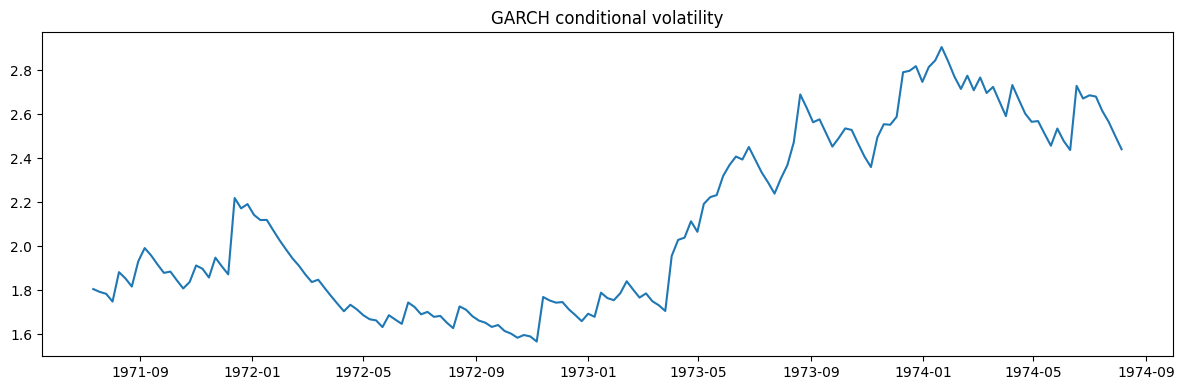

In [9]:
cond_vol = garch_res.conditional_volatility
cond_vol = pd.Series(cond_vol, index=arima_resid.index).dropna()

plt.figure(figsize=(12, 4))
plt.plot(cond_vol.index, cond_vol.values)
plt.title('GARCH conditional volatility')
plt.tight_layout()
plt.show()

В работе был рассмотрен временной ряд недельных закрытий индекса Dow Jones.
Поскольку модель GARCH применима только к стационарным рядам, исходный ряд уровней был преобразован в лог-доходности, стационарность которых подтверждена тестом Дики–Фуллера.

Для стационарного ряда доходностей были подобраны оптимальные параметры ARIMA по критерию AIC. Лучшая модель - ARIMA(2,0,2).
После этого была построена модель условной дисперсии GARCH(1,1) со Student-t распределением ошибок на остатках ARIMA.

ARCH LM тест показал, что до применения GARCH выраженный ARCH-эффект в остатках ARIMA отсутствует, а после применения GARCH остаточный ARCH-эффект также не выявляется.
Это означает, что модель GARCH корректно описывает волатильность, однако дополнительный выигрыш от её применения для данного ряда ограничен, так как выраженной кластеризации волатильности в данных нет.

Таким образом, ARIMA хорошо описывает динамику среднего значения ряда, а использование GARCH в данном случае носит скорее диагностический характер и не является критически необходимым, что согласуется с результатами статистических тестов.

GARCH не дал сильного эффекта, потому что в остатках ARIMA отсутствует выраженный ARCH-эффект, и условная дисперсия в данных близка к постоянной.